# TimeGAN for Synthetic Financial Data Generation

This notebook implements TimeGAN to generate synthetic data based on `train_sequences.csv`.
Designed for Google Colab with GPU acceleration (H100/A100 recommended for speed).

In [1]:
# @title 1. Install Dependencies & Imports
# Ensure we have the necessary libraries
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import os
import time

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.test.is_gpu_available()}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow Version: 2.19.0
GPU Available: True


In [2]:
# @title 2. Upload Data
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Uploaded: {filename}")

Saving train_sequences.csv to train_sequences (1).csv
Uploaded: train_sequences (1).csv


In [3]:
# @title 3. Data Loading & Preprocessing

def load_data(filename, seq_len=24):
    """
    Reads CSV and converts to 3D numpy array.
    Expected format: sequence_id, time_step, features...
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} not found!")

    print(f"Loading data from {filename}...")
    df = pd.read_csv(filename)

    # Select feature columns (assumes first 2 cols are ID and time_step)
    feature_cols = df.columns[2:]
    print(f"Features detected: {list(feature_cols)}")

    num_sequences = df['sequence_id'].nunique()
    total_rows = len(df)

    # Fast reshape if data is perfectly rectangular
    if total_rows % seq_len == 0 and (total_rows // seq_len) == num_sequences:
        print("Data dimensions are perfect for quick reshaping.")
        data_features = df[feature_cols].values
        # (Samples, Time, Features)
        data_3d = data_features.reshape((num_sequences, seq_len, len(feature_cols)))
    else:
        print("Data dimensions require manual grouping (slow)... Check if sequence length is exactly 24 for all IDs.")
        data_list = []
        grouped = df.groupby('sequence_id')
        for _, group in grouped:
            if len(group) == seq_len:
                data_list.append(group[feature_cols].values)
        data_3d = np.array(data_list)

    print(f"Data Shape: {data_3d.shape}") # (N, 24, 4)
    return data_3d

# Load the data
try:
    real_data = load_data(filename, seq_len=24)
except NameError:
    print("Please upload a file in the previous step!")

Loading data from train_sequences (1).csv...
Features detected: ['log_ret_open_norm', 'log_ret_high_norm', 'log_ret_low_norm', 'log_ret_close_norm']
Data dimensions are perfect for quick reshaping.
Data Shape: (80468, 24, 4)


In [4]:
# @title 4. TimeGAN Model Architecture

class TimeGAN:
    def __init__(self, seq_len, n_seq, hidden_dim=24, num_layers=3, batch_size=128):
        self.seq_len = seq_len
        self.n_seq = n_seq # feature count
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.batch_size = batch_size

        # Components
        self.embedder = self.build_embedder()
        self.recovery = self.build_recovery()
        self.generator = self.build_generator()
        self.supervisor = self.build_supervisor()
        self.discriminator = self.build_discriminator()

    def make_rnn_layers(self, name_prefix):
        layers = []
        for i in range(self.num_layers):
            layers.append(tf.keras.layers.GRU(
                units=self.hidden_dim,
                return_sequences=True,
                activation='tanh',
                name=f'{name_prefix}_gru_{i}'
            ))
        return layers

    def build_embedder(self):
        model = tf.keras.Sequential(name='Embedder')
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.n_seq)))
        for layer in self.make_rnn_layers('embedder'):
            model.add(layer)
        model.add(tf.keras.layers.Dense(self.hidden_dim, activation='sigmoid'))
        return model

    def build_recovery(self):
        model = tf.keras.Sequential(name='Recovery')
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.hidden_dim)))
        for layer in self.make_rnn_layers('recovery'):
            model.add(layer)
        model.add(tf.keras.layers.Dense(self.n_seq, activation='sigmoid'))
        return model

    def build_generator(self):
        model = tf.keras.Sequential(name='Generator')
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.n_seq)))
        for layer in self.make_rnn_layers('generator'):
            model.add(layer)
        model.add(tf.keras.layers.Dense(self.hidden_dim, activation='sigmoid'))
        return model

    def build_supervisor(self):
        model = tf.keras.Sequential(name='Supervisor')
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.hidden_dim)))
        for layer in self.make_rnn_layers('supervisor'):
            model.add(layer)
        model.add(tf.keras.layers.Dense(self.hidden_dim, activation='sigmoid'))
        return model

    def build_discriminator(self):
        model = tf.keras.Sequential(name='Discriminator')
        model.add(tf.keras.layers.Input(shape=(self.seq_len, self.hidden_dim)))
        for layer in self.make_rnn_layers('discriminator'):
            model.add(layer)
        model.add(tf.keras.layers.Dense(1, activation=None))
        return model

print("Model classes defined.")

Model classes defined.


In [5]:
# @title 5. Training Loop

def train_timegan(data, parameters):
    hidden_dim = parameters['hidden_dim']
    num_layers = parameters['num_layers']
    iterations = parameters['iterations']
    batch_size = parameters['batch_size']

    no, seq_len, dim = data.shape

    # Model Init
    timegan = TimeGAN(seq_len=seq_len, n_seq=dim, hidden_dim=hidden_dim, num_layers=num_layers)

    # Optimizers
    embedder_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    recovery_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    supervisor_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    # Loss functions
    mse_loss = tf.keras.losses.MeanSquaredError()
    bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def train_autoencoder(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            x_tilde = timegan.recovery(h)
            loss = mse_loss(x, x_tilde)
            loss_0 = 10 * tf.sqrt(loss)

        vars = timegan.embedder.trainable_variables + timegan.recovery.trainable_variables
        gradients = tape.gradient(loss_0, vars)
        embedder_optimizer.apply_gradients(zip(gradients, vars))
        return loss_0

    @tf.function
    def train_supervisor(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h)
            loss = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])

        vars = timegan.supervisor.trainable_variables + timegan.generator.trainable_variables
        gradients = tape.gradient(loss, vars)
        supervisor_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    @tf.function
    def train_embedder_supervisor(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h)
            x_tilde = timegan.recovery(h)
            loss_rec = mse_loss(x, x_tilde)
            loss_su = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])
            loss = 10 * tf.sqrt(loss_rec) + 0.1 * loss_su

        vars = timegan.embedder.trainable_variables + timegan.recovery.trainable_variables + \
               timegan.supervisor.trainable_variables + timegan.generator.trainable_variables
        gradients = tape.gradient(loss, vars)
        generator_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    @tf.function
    def train_generator(x, z):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h)
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_fake = timegan.discriminator(h_hat)
            loss_gen_unsupervised = bce_loss(tf.ones_like(y_fake), y_fake)
            loss_su_gen = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])
            loss = loss_su_gen + loss_gen_unsupervised + 100 * tf.sqrt(loss_su_gen)

        vars = timegan.generator.trainable_variables + timegan.supervisor.trainable_variables
        gradients = tape.gradient(loss, vars)
        generator_optimizer.apply_gradients(zip(gradients, vars))
        return loss, loss_gen_unsupervised

    @tf.function
    def train_discriminator(x, z):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_real = timegan.discriminator(h)
            y_fake = timegan.discriminator(h_hat)
            loss_real = bce_loss(tf.ones_like(y_real), y_real)
            loss_fake = bce_loss(tf.zeros_like(y_fake), y_fake)
            loss = loss_real + loss_fake

        vars = timegan.discriminator.trainable_variables
        gradients = tape.gradient(loss, vars)
        discriminator_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    print("Training initiated...")

    # 1. Embedding Network Training
    print("Start Embedding Network Training")
    for i in range(iterations):
        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        step_loss = train_autoencoder(x_batch)
        if i % 1000 == 0:
            print(f'Step: {i}/{iterations}, Loss: {step_loss.numpy():.4f}')

    # 2. Supervised Loss Training
    print("Start Training with Supervised Loss Only")
    for i in range(iterations):
        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        step_loss = train_supervisor(x_batch)
        if i % 1000 == 0:
            print(f'Step: {i}/{iterations}, Loss: {step_loss.numpy():.4f}')

    # 3. Joint Training
    print("Start Joint Training")
    for i in range(iterations):
        for _ in range(2):
            idx = np.random.randint(0, no, batch_size)
            x_batch = tf.cast(data[idx], dtype=tf.float32)
            z_batch = tf.cast(np.random.normal(0, 1, size=(batch_size, seq_len, dim)), dtype=tf.float32)
            g_loss, g_loss_u = train_generator(x_batch, z_batch)

        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        e_loss = train_embedder_supervisor(x_batch)

        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        z_batch = tf.cast(np.random.normal(0, 1, size=(batch_size, seq_len, dim)), dtype=tf.float32)
        d_loss = train_discriminator(x_batch, z_batch)

        if i % 100 == 0:
            print(f'Step: {i}/{iterations}, D_Loss: {d_loss.numpy():.4f}, G_Loss: {g_loss.numpy():.4f}, E_Loss: {e_loss.numpy():.4f}')

    print("Training finished!")
    return timegan

In [6]:
# @title 6. Visualization & Generation Functions

def generate_synthetic_data(timegan, n_samples, dim):
    z_batch = np.random.normal(0, 1, size=(n_samples, timegan.seq_len, dim))
    z_batch = tf.cast(z_batch, dtype=tf.float32)

    e_hat = timegan.generator(z_batch)
    h_hat = timegan.supervisor(e_hat)
    x_hat = timegan.recovery(h_hat)

    return x_hat.numpy()

def visualize(real_data, synth_data):
    sample_size = min(2000, len(real_data))
    idx = np.random.permutation(len(real_data))[:sample_size]

    real_sample = real_data[idx]
    synth_sample = synth_data[:sample_size]

    N, T, D = real_sample.shape
    real_flatten = real_sample.reshape(N, -1)
    synth_flatten = synth_sample.reshape(N, -1)

    # PCA
    print("Calculating PCA...")
    pca = PCA(n_components=2)
    pca.fit(real_flatten)
    pca_real = pca.transform(real_flatten)
    pca_synth = pca.transform(synth_flatten)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(pca_real[:, 0], pca_real[:, 1], c='red', alpha=0.2, label='Original')
    plt.scatter(pca_synth[:, 0], pca_synth[:, 1], c='blue', alpha=0.2, label='Synthetic')
    plt.legend()
    plt.title('PCA Results')

    # t-SNE
    print("Calculating t-SNE...")
    tsne_sample_size = min(500, N)
    prep_data = np.concatenate((real_flatten[:tsne_sample_size], synth_flatten[:tsne_sample_size]), axis=0)
    tsne = TSNE(n_components=2, verbose=0, perplexity=40, n_iter=300)
    tsne_results = tsne.fit_transform(prep_data)

    plt.subplot(1, 2, 2)
    plt.scatter(tsne_results[:tsne_sample_size, 0], tsne_results[:tsne_sample_size, 1], c='red', alpha=0.2, label='Original')
    plt.scatter(tsne_results[tsne_sample_size:, 0], tsne_results[tsne_sample_size:, 1], c='blue', alpha=0.2, label='Synthetic')
    plt.legend()
    plt.title('t-SNE Results')
    plt.show()

    # Distributions
    print("Plotting distributions...")
    plt.figure(figsize=(14, 8))
    for i in range(D):
        plt.subplot(2, 2, i+1)
        sns.histplot(real_sample[:, :, i].flatten(), color='red', label='Original', kde=True, stat="density", alpha=0.3)
        sns.histplot(synth_sample[:, :, i].flatten(), color='blue', label='Synthetic', kde=True, stat="density", alpha=0.3)
        plt.title(f'Feature {i} Distribution')
        plt.legend()

In [9]:
# @title 7. Run Training

# Set Parameters (Adjust 'iterations' based on preference)
parameters = {
    'hidden_dim': 24,
    'num_layers': 3,
    'iterations': 3000, # with A100/H100 you can go higher, e.g. 5000+
    'batch_size': 128
}


def train_timegan(data, parameters):
    hidden_dim = parameters['hidden_dim']
    num_layers = parameters['num_layers']
    iterations = parameters['iterations']
    batch_size = parameters['batch_size']

    no, seq_len, dim = data.shape

    # Model Init
    timegan = TimeGAN(seq_len=seq_len, n_seq=dim, hidden_dim=hidden_dim, num_layers=num_layers)

    # Optimizers
    embedder_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    recovery_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    supervisor_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    # NEW: Dedicated optimizer for the joint embedder-generator training step
    joint_embedder_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    # Loss functions
    mse_loss = tf.keras.losses.MeanSquaredError()
    bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def train_autoencoder(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            x_tilde = timegan.recovery(h)
            loss = mse_loss(x, x_tilde)
            loss_0 = 10 * tf.sqrt(loss)

        vars = timegan.embedder.trainable_variables + timegan.recovery.trainable_variables
        gradients = tape.gradient(loss_0, vars)
        embedder_optimizer.apply_gradients(zip(gradients, vars))
        return loss_0

    @tf.function
    def train_supervisor(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h)
            loss = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])

        vars = timegan.supervisor.trainable_variables + timegan.generator.trainable_variables
        gradients = tape.gradient(loss, vars)
        supervisor_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    @tf.function
    def train_embedder_supervisor(x):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h)
            x_tilde = timegan.recovery(h)
            loss_rec = mse_loss(x, x_tilde)
            loss_su = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])
            loss = 10 * tf.sqrt(loss_rec) + 0.1 * loss_su

        vars = timegan.embedder.trainable_variables + timegan.recovery.trainable_variables + \
               timegan.supervisor.trainable_variables + timegan.generator.trainable_variables
        gradients = tape.gradient(loss, vars)
        # NEW: Use the dedicated joint_embedder_gen_optimizer
        joint_embedder_gen_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    @tf.function
    def train_generator(x, z):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            h_hat_supervise = timegan.supervisor(h) # ADDED THIS LINE
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_fake = timegan.discriminator(h_hat)
            loss_gen_unsupervised = bce_loss(tf.ones_like(y_fake), y_fake)
            loss_su_gen = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])
            loss = loss_su_gen + loss_gen_unsupervised + 100 * tf.sqrt(loss_su_gen)

        vars = timegan.generator.trainable_variables + timegan.supervisor.trainable_variables
        gradients = tape.gradient(loss, vars)
        generator_optimizer.apply_gradients(zip(gradients, vars))
        return loss, loss_gen_unsupervised

    @tf.function
    def train_discriminator(x, z):
        with tf.GradientTape() as tape:
            h = timegan.embedder(x)
            e_hat = timegan.generator(z)
            h_hat = timegan.supervisor(e_hat)
            y_real = timegan.discriminator(h)
            y_fake = timegan.discriminator(h_hat)
            loss_real = bce_loss(tf.ones_like(y_real), y_real)
            loss_fake = bce_loss(tf.zeros_like(y_fake), y_fake)
            loss = loss_real + loss_fake

        vars = timegan.discriminator.trainable_variables
        gradients = tape.gradient(loss, vars)
        discriminator_optimizer.apply_gradients(zip(gradients, vars))
        return loss

    print("Training initiated...")

    # 1. Embedding Network Training
    print("Start Embedding Network Training")
    for i in range(iterations):
        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        step_loss = train_autoencoder(x_batch)
        if i % 1000 == 0:
            print(f'Step: {i}/{iterations}, Loss: {step_loss.numpy():.4f}')

    # 2. Supervised Loss Training
    print("Start Training with Supervised Loss Only")
    for i in range(iterations):
        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        step_loss = train_supervisor(x_batch)
        if i % 1000 == 0:
            print(f'Step: {i}/{iterations}, Loss: {step_loss.numpy():.4f}')

    # 3. Joint Training
    print("Start Joint Training")
    for i in range(iterations):
        for _ in range(2):
            idx = np.random.randint(0, no, batch_size)
            x_batch = tf.cast(data[idx], dtype=tf.float32)
            z_batch = tf.cast(np.random.normal(0, 1, size=(batch_size, seq_len, dim)), dtype=tf.float32)
            g_loss, g_loss_u = train_generator(x_batch, z_batch)

        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        e_loss = train_embedder_supervisor(x_batch) # This now uses the new optimizer

        idx = np.random.randint(0, no, batch_size)
        x_batch = tf.cast(data[idx], dtype=tf.float32)
        z_batch = tf.cast(np.random.normal(0, 1, size=(batch_size, seq_len, dim)), dtype=tf.float32)
        d_loss = train_discriminator(x_batch, z_batch)

        if i % 100 == 0:
            print(f'Step: {i}/{iterations}, D_Loss: {d_loss.numpy():.4f}, G_Loss: {g_loss.numpy():.4f}, E_Loss: {e_loss.numpy():.4f}')

    print("Training finished!")
    return timegan

# Start Process
model = train_timegan(real_data, parameters)

# Generate
print("Generating synthetic data...")
synthetic_data = generate_synthetic_data(model, n_samples=len(real_data), dim=real_data.shape[2])

# Save
np.save('synthetic_data_timegan.npy', synthetic_data)
print("Saved synthetic data to 'synthetic_data_timegan.npy'")

Training initiated...
Start Embedding Network Training
Step: 0/3000, Loss: 5.4564
Step: 1000/3000, Loss: 2.2991
Step: 2000/3000, Loss: 2.1729
Start Training with Supervised Loss Only


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Generator/generator_gru_0/gru_cell/kernel', 'Generator/generator_gru_0/gru_cell/recurrent_kernel', 'Generator/generator_gru_0/gru_cell/bias', 'Generator/generator_gru_1/gru_cell/kernel', 'Generator/generator_gru_1/gru_cell/recurrent_kernel', 'Generator/generator_gru_1/gru_cell/bias', 'Generator/generator_gru_2/gru_cell/kernel', 'Generator/generator_gru_2/gru_cell/recurrent_kernel', 'Generator/generator_gru_2/gru_cell/bias', 'Generator/dense_12/kernel', 'Generator/dense_12/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Step: 0/3000, Loss: 0.0648
Step: 1000/3000, Loss: 0.0137
Step: 2000/3000, Loss: 0.0148
Start Joint Training
Step: 0/3000, D_Loss: 1.3528, G_Loss: 13.0390, E_Loss: 2.1079
Step: 100/3000, D_Loss: 1.2837, G_Loss: 12.7625, E_Loss: 1.9856
Step: 200/3000, D_Loss: 1.6409, G_Loss: 11.9010, E_Loss: 2.1099
Step: 300/3000, D_Loss: 1.3509, G_Loss: 11.4441, E_Loss: 2.1862
Step: 400/3000, D_Loss: 1.3733, G_Loss: 10.9860, E_Loss: 2.1131
Step: 500/3000, D_Loss: 1.3562, G_Loss: 10.6604, E_Loss: 2.0529
Step: 600/3000, D_Loss: 1.3700, G_Loss: 10.5289, E_Loss: 2.2285
Step: 700/3000, D_Loss: 1.5019, G_Loss: 9.8268, E_Loss: 2.0747
Step: 800/3000, D_Loss: 1.5909, G_Loss: 10.6548, E_Loss: 2.1582
Step: 900/3000, D_Loss: 1.4220, G_Loss: 9.6659, E_Loss: 1.9982
Step: 1000/3000, D_Loss: 1.3288, G_Loss: 9.4788, E_Loss: 2.0899
Step: 1100/3000, D_Loss: 1.3522, G_Loss: 9.3366, E_Loss: 2.2374
Step: 1200/3000, D_Loss: 1.3435, G_Loss: 9.0180, E_Loss: 2.1337
Step: 1300/3000, D_Loss: 1.4232, G_Loss: 8.9409, E_Loss: 2.1405


Calculating PCA...
Calculating t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


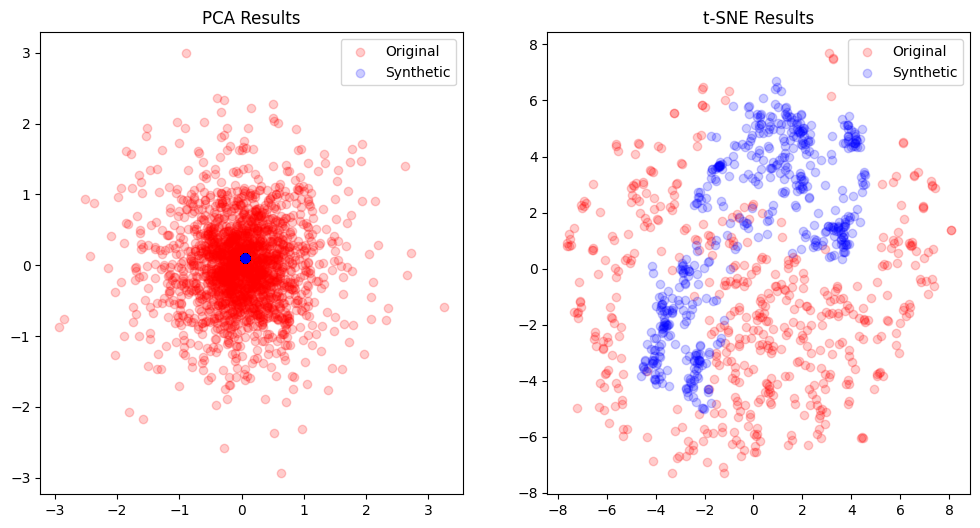

Plotting distributions...


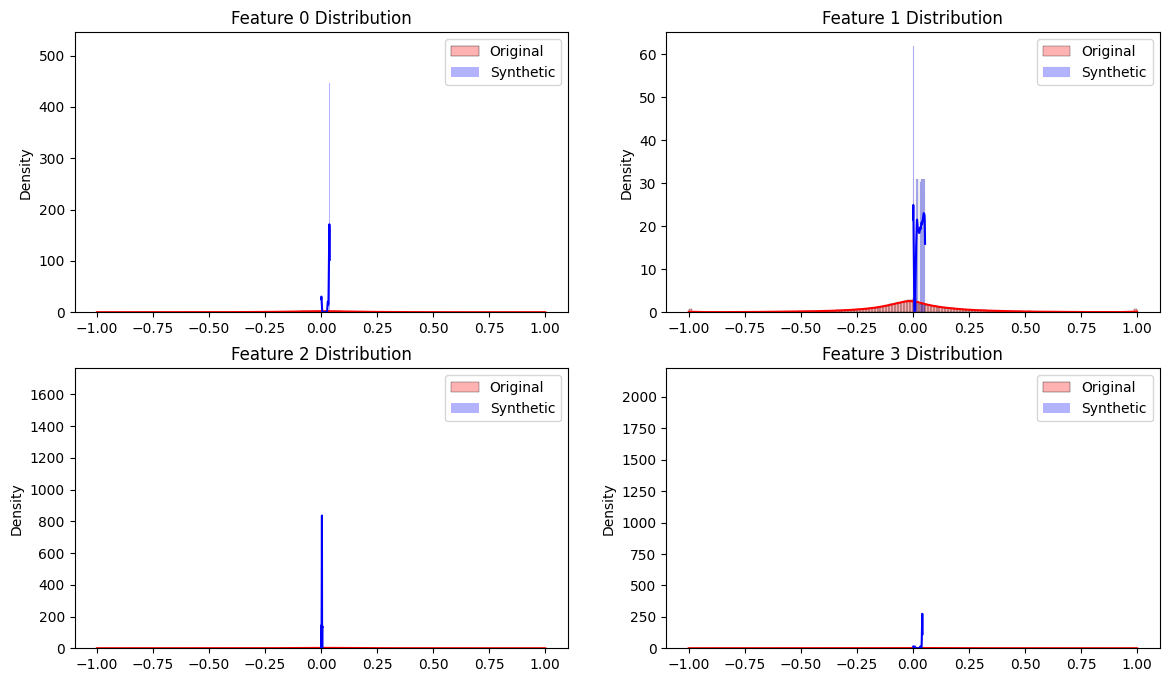

In [10]:
# @title 8. Visualize Results
visualize(real_data, synthetic_data)

### Sentetik Log Getirilerini Fiyatlara Dönüştürme

Modelimiz, `log_ret_open_norm`, `log_ret_high_norm`, `log_ret_low_norm`, `log_ret_close_norm` olarak adlandırılan normalleştirilmiş log getirileri üretti. Notebook'ta bu normalleştirmenin tam yöntemleri veya denormalizasyon için gereken parametreler (örneğin, ortalama ve standart sapma) bulunmadığından, bu `_norm` değerlerini doğrudan ham log getirileri olarak kabul ederek ilerleyeceğiz.

Fiyatları yeniden yapılandırmak için aşağıdaki varsayımları kullanacağız:
- İlk özellik (`log_ret_open_norm`): `log(açılış_fiyatı_t / kapanış_fiyatı_{t-1})`
- İkinci özellik (`log_ret_high_norm`): `log(yüksek_fiyat_t / açılış_fiyatı_t)`
- Üçüncü özellik (`log_ret_low_norm`): `log(düşük_fiyat_t / açılış_fiyatı_t)`
- Dördüncü özellik (`log_ret_close_norm`): `log(kapanış_fiyatı_t / açılış_fiyatı_t)`

Bu varsayımlarla, sağlanan başlangıç fiyatından başlayarak sentetik log getirilerini mum fiyatlarına dönüştüren bir fonksiyon uygulayacağız.

In [11]:
def log_returns_to_prices(log_returns_sequences, initial_price):
    """
    Converts sequences of log returns (OHLC) to price sequences.
    Assumes log_returns_sequences are structured as (num_samples, seq_len, 4)
    where features are [log(open/prev_close), log(high/open), log(low/open), log(close/open)].

    Args:
        log_returns_sequences (np.ndarray): 3D array of synthetic log returns.
                                            Shape: (num_samples, seq_len, 4).
        initial_price (float): The starting closing price for the first sequence.

    Returns:
        np.ndarray: 3D array of synthetic OHLC prices.
                    Shape: (num_samples, seq_len, 4).
    """
    num_samples, seq_len, num_features = log_returns_sequences.shape
    price_sequences = np.zeros_like(log_returns_sequences)

    # Iterate through each generated sequence independently
    for s in range(num_samples):
        # For each sequence, the 'previous close' for the very first candle
        # is the initial_price provided.
        prev_close = initial_price

        for t in range(seq_len):
            log_ret_open = log_returns_sequences[s, t, 0]
            log_ret_high_from_open = log_returns_sequences[s, t, 1]
            log_ret_low_from_open = log_returns_sequences[s, t, 2]
            log_ret_close_from_open = log_returns_sequences[s, t, 3]

            current_open = prev_close * np.exp(log_ret_open)
            # High, Low, Close relative to current Open
            current_high = current_open * np.exp(log_ret_high_from_open)
            current_low = current_open * np.exp(log_ret_low_from_open)
            current_close = current_open * np.exp(log_ret_close_from_open)

            # Ensure high is indeed highest and low is lowest within the candle
            # This step adds robustness as log returns might generate inconsistencies
            prices_in_candle = sorted([current_open, current_high, current_low, current_close])
            current_high = prices_in_candle[3]
            current_low = prices_in_candle[0]

            price_sequences[s, t, 0] = current_open
            price_sequences[s, t, 1] = current_high
            price_sequences[s, t, 2] = current_low
            price_sequences[s, t, 3] = current_close

            prev_close = current_close # Update prev_close for the next time step in the sequence

    return price_sequences

In [12]:
# Kullanıcının belirttiği başlangıç fiyatı
initial_reference_price = 1.16821

# Sentetik log getirilerini fiyatlara dönüştür
synthetic_ohlc_prices = log_returns_to_prices(synthetic_data, initial_reference_price)

print("Sentetik OHLC Fiyatlarının İlk 5 Dizisi (Başlangıç Fiyatı: 1.16821):")
# İlk 5 sentetik dizinin ilk 3 mumunu göster
for i in range(min(5, synthetic_ohlc_prices.shape[0])):
    print(f"\nSequence {i+1}:")
    display(pd.DataFrame(synthetic_ohlc_prices[i, :3, :], columns=['Open', 'High', 'Low', 'Close']))

Sentetik OHLC Fiyatlarının İlk 5 Dizisi (Başlangıç Fiyatı: 1.16821):

Sequence 1:


,Open,High,Low,Close
0,1.170753,1.180398,1.170753,1.180398
1,1.181633,1.183505,1.181633,1.183505
2,1.183636,1.222382,1.183636,1.222382



Sequence 2:


,Open,High,Low,Close
0,1.170752,1.180392,1.170752,1.180392
1,1.181631,1.183482,1.181631,1.183482
2,1.183611,1.222546,1.183611,1.222546



Sequence 3:


,Open,High,Low,Close
0,1.170758,1.180425,1.170758,1.180425
1,1.181672,1.183534,1.181672,1.183534
2,1.183664,1.222621,1.183664,1.222621



Sequence 4:


,Open,High,Low,Close
0,1.170753,1.180398,1.170753,1.180398
1,1.181636,1.183491,1.181636,1.183491
2,1.183620,1.222499,1.183620,1.222499



Sequence 5:


,Open,High,Low,Close
0,1.170752,1.180398,1.170752,1.180398
1,1.181640,1.183476,1.181640,1.183476
2,1.183605,1.222587,1.183605,1.222587


In [14]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


Displaying Candlestick Chart for Synthetic Sequence 1 (First 24 Candles):


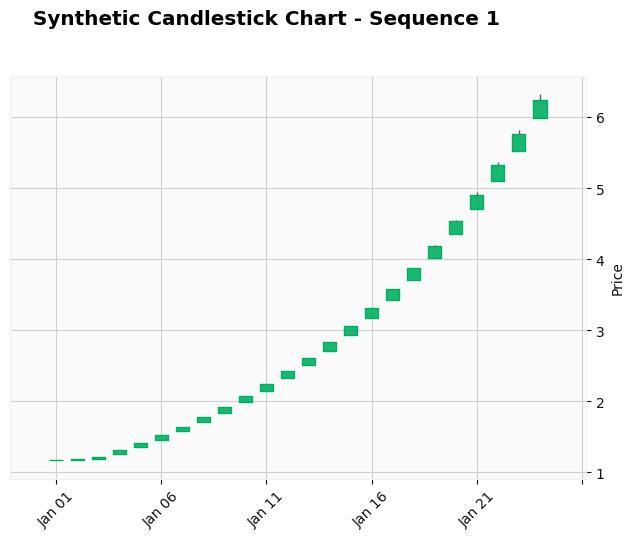

In [16]:
import mplfinance as mpf
import pandas as pd

# Visualize the first synthetic sequence
sample_sequence_index = 0  # You can change this to view other sequences
num_candles_to_plot = synthetic_ohlc_prices.shape[1] # Set to actual sequence length

synthetic_sequence_data = synthetic_ohlc_prices[sample_sequence_index, :num_candles_to_plot, :]

# Create a DataFrame for mplfinance
df_ohlc = pd.DataFrame(
    synthetic_sequence_data,
    columns=['Open', 'High', 'Low', 'Close'],
    index=pd.to_datetime(range(num_candles_to_plot), unit='D', origin='2023-01-01') # Dummy date index
)

# Plotting the candlestick chart
print(f"Displaying Candlestick Chart for Synthetic Sequence {sample_sequence_index + 1} (First {num_candles_to_plot} Candles):")
mpf.plot(df_ohlc, type='candle', style='yahoo', title=f'Synthetic Candlestick Chart - Sequence {sample_sequence_index + 1}', ylabel='Price')